In [1]:
#importing required libraries to work on implementing linear regression model-
# from Numpy, Pandas, Matplotlib, Scipy, plotly, Sklearn, statsmodels

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
from matplotlib import pyplot as plot

import scipy.stats as st
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

import statsmodels.stats.diagnostic as di
import statsmodels.stats.stattools as stt
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.stats.diagnostic import het_breuschpagan

import warnings
warnings.filterwarnings('ignore')


# Data Preparation

In [2]:
#reading all the columns from the dataset file from root

housing_df=pd.read_csv("./housing.csv")


In [3]:
# dividing the dataset as 80:20 with the seed as student id and assigning it to the train and test datasets

X=housing_df.drop(['Sale_Price'],axis=1)
y=housing_df['Sale_Price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22188801)

In [4]:
#adding back the dependent variable-y ->Sale_Price to the train and test dataset 

train_data=X_train.join(y_train)
test_data=X_test.join(y_test)

# Data Cleaning

In [5]:
#looking for any cells in the dataframe with NA as a value in training dataset
train_data.isna().sum()

Lot_Frontage     0
Lot_Area         0
Bldg_Type        0
House_Style      0
Overall_Cond     0
Year_Built       0
Exter_Cond       0
Total_Bsmt_SF    0
First_Flr_SF     0
Second_Flr_SF    0
Full_Bath        0
Half_Bath        0
Bedroom_AbvGr    0
Kitchen_AbvGr    0
Fireplaces       0
Longitude        0
Latitude         0
Sale_Price       0
dtype: int64

In [6]:
#looking for any cells in the dataframe with null value in training dataset

train_data.isnull().sum()

Lot_Frontage     0
Lot_Area         0
Bldg_Type        0
House_Style      0
Overall_Cond     0
Year_Built       0
Exter_Cond       0
Total_Bsmt_SF    0
First_Flr_SF     0
Second_Flr_SF    0
Full_Bath        0
Half_Bath        0
Bedroom_AbvGr    0
Kitchen_AbvGr    0
Fireplaces       0
Longitude        0
Latitude         0
Sale_Price       0
dtype: int64

In [7]:
# looking at the distribution of numerical data in the training to understand the distribution of the data
train_data.describe()

,Lot_Frontage,Lot_Area,Year_Built,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Fireplaces,Longitude,Latitude,Sale_Price
count,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000
mean,55.499482,9945.910363,1968.527979,1023.133679,1133.119171,341.092228,1.535233,0.379793,2.854922,1.041451,0.608808,-93.641842,42.034031,175436.430052
std,33.253012,7364.701883,29.660993,411.547508,364.324768,423.537302,0.547441,0.499150,0.826398,0.201965,0.658969,0.026075,0.017732,72455.388305
min,0.000000,1300.000000,1875.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-93.693153,41.986498,35000.000000
25%,39.000000,7288.500000,1951.000000,783.000000,864.000000,0.000000,1.000000,0.000000,2.000000,1.000000,0.000000,-93.660284,42.022238,129212.500000
50%,60.000000,9350.000000,1970.000000,970.000000,1060.000000,0.000000,2.000000,0.000000,3.000000,1.000000,1.000000,-93.639447,42.034617,157500.000000
75%,76.000000,11344.750000,1997.000000,1244.000000,1348.500000,703.750000,2.000000,1.000000,3.000000,1.000000,1.000000,-93.621376,42.047985,205000.000000
max,313.000000,215245.000000,2010.000000,3206.000000,3228.000000,1872.000000,4.000000,2.000000,6.000000,3.000000,4.000000,-93.577427,42.063381,755000.000000


In [8]:
categorical_columns= train_data.select_dtypes(object)
categorical_columns.describe()

,Bldg_Type,House_Style,Overall_Cond,Exter_Cond
count,1930,1930,1930,1930
unique,5,8,9,5
top,OneFam,One_Story,Average,Typical
freq,1600,940,1008,1665


## Exploratory Data Analysis

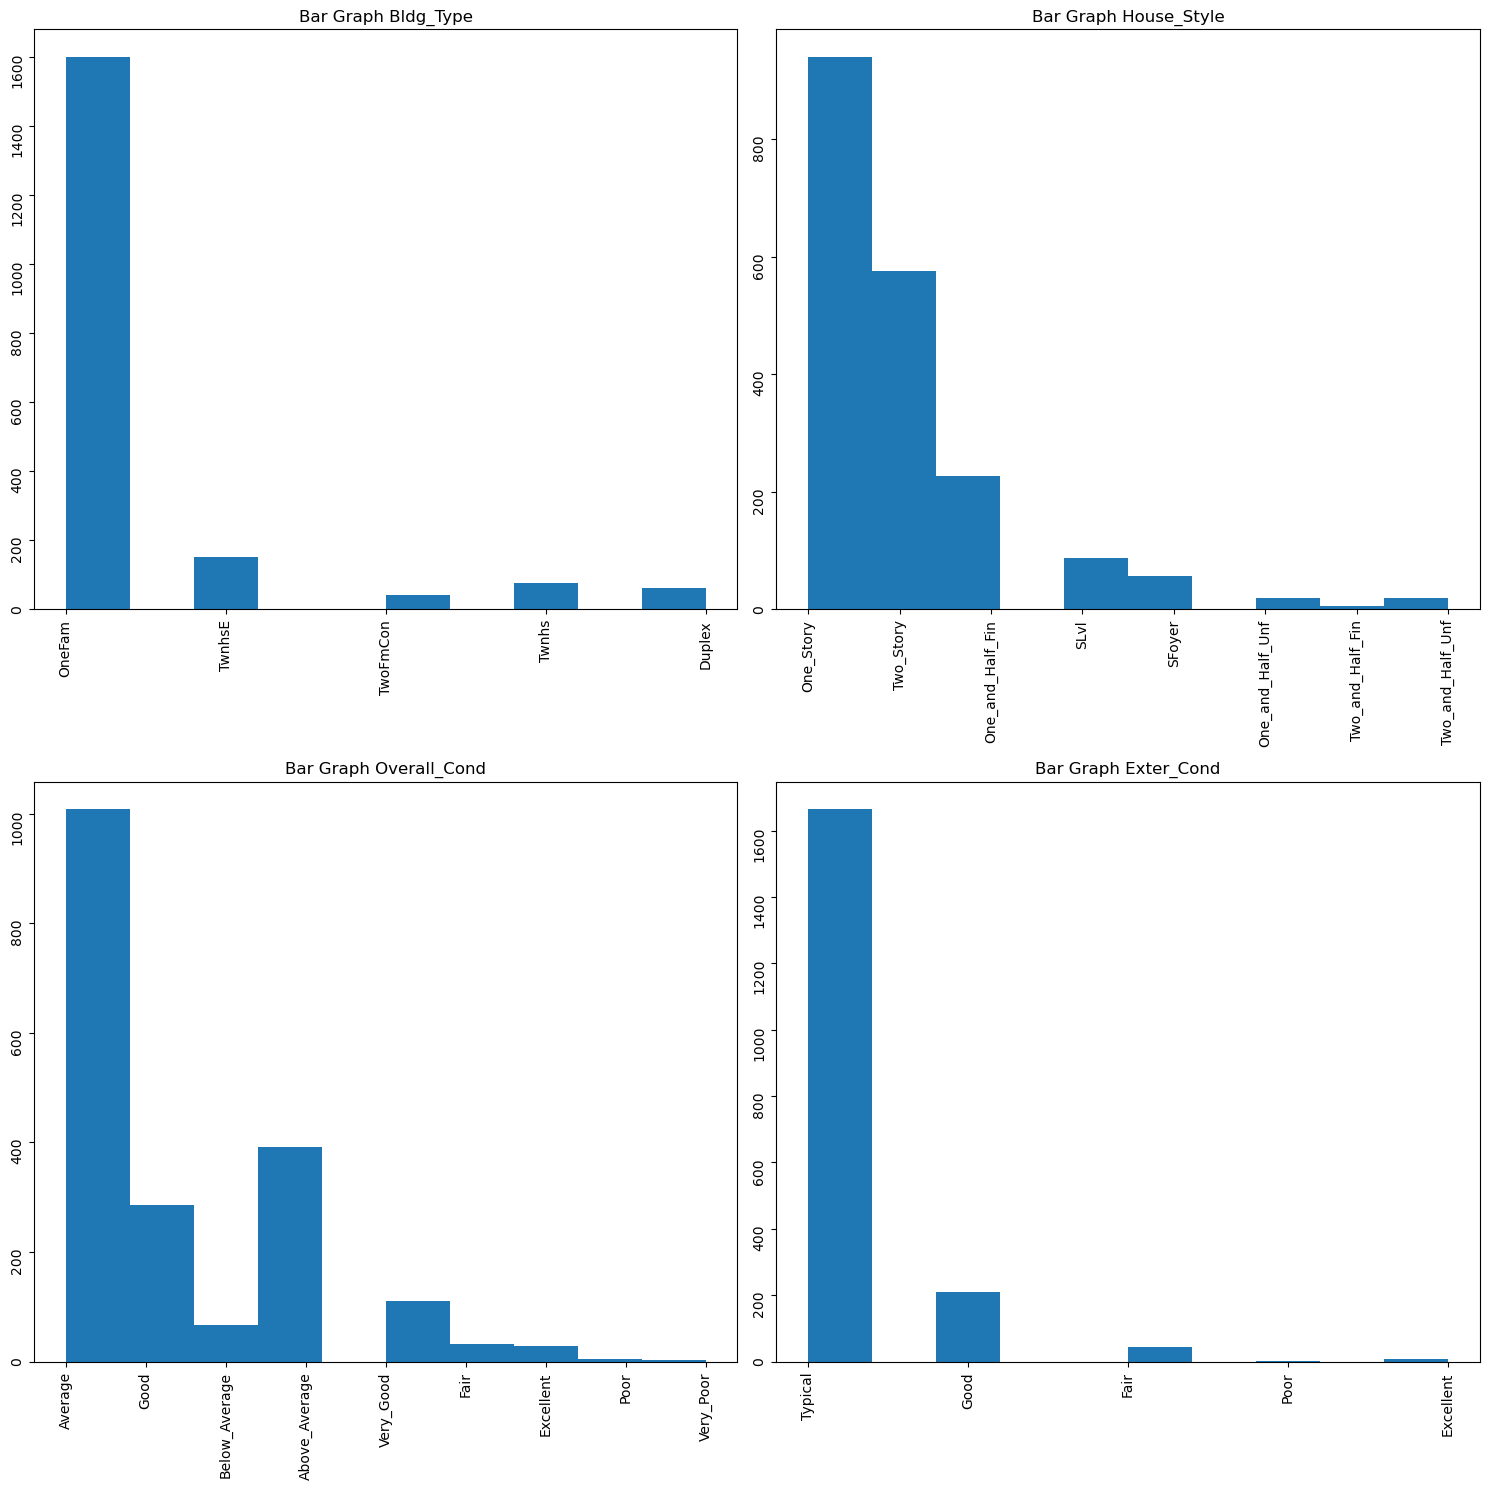

In [9]:
# Barchart to understand the distribution of the categorical - Nominal and Ordinal data

categorical_list=train_data.columns.values.tolist()

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2,figsize=(15,15))

ax0.hist(categorical_columns['Bldg_Type'], histtype='bar',label='vertical')
ax0.set_title('Bar Graph Bldg_Type')
ax0.tick_params(labelrotation=90)

ax1.hist(categorical_columns['House_Style'], histtype='bar')
ax1.set_title('Bar Graph House_Style')
ax1.tick_params(labelrotation=90)

ax2.hist(categorical_columns['Overall_Cond'], histtype='bar')
ax2.set_title('Bar Graph Overall_Cond')
ax2.tick_params(labelrotation=90)

ax3.hist(categorical_columns['Exter_Cond'], histtype='bar')
ax3.set_title('Bar Graph Exter_Cond')
ax3.tick_params(labelrotation=90)

plt.tight_layout()
plt.show()


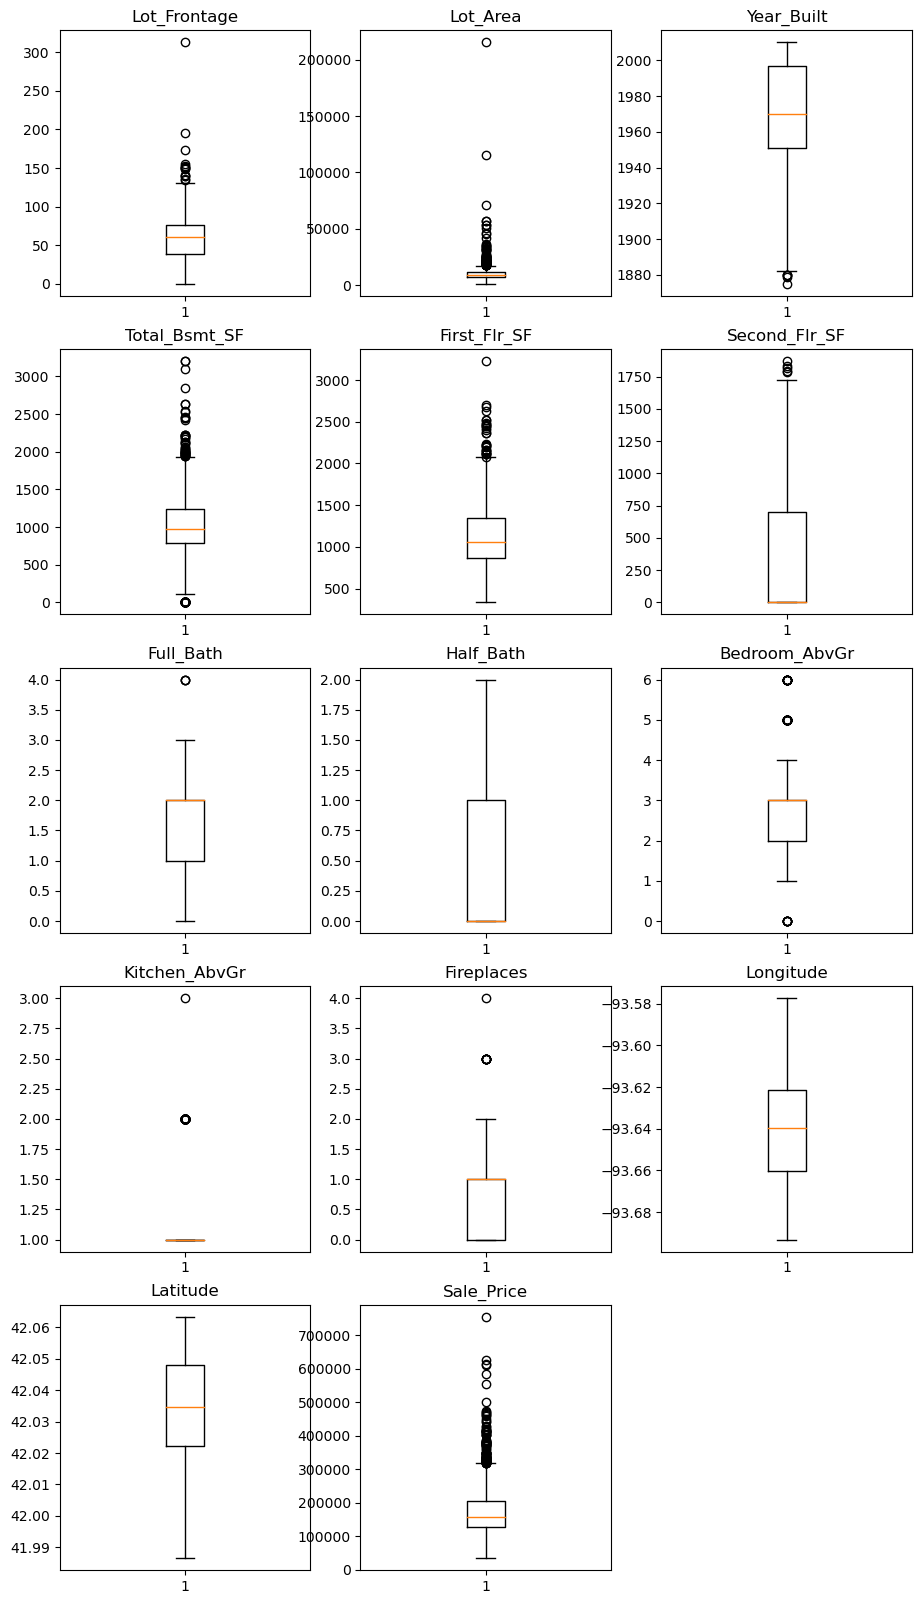

In [10]:
#Boxplot to visualize the distribution of the numerical features in the dataset

numerical_columns=train_data.select_dtypes(["int64","float64"])
num_cols = 14
num_rows = 3
fig, axes = plt.subplots(5, 3, figsize=(11, 20))
axes = axes.flatten()

for i, j in enumerate(numerical_columns.columns):
    if i < num_cols:
        ax = axes[i]
        ax.boxplot(numerical_columns[j])
        ax.set_title(j)
fig.delaxes(axes[14])

plt.show()
#Outliers are identified in Lot_frontage, Lot_Area,Total_Bsmt_SF,First_Flr_SF,..., Sale_Price

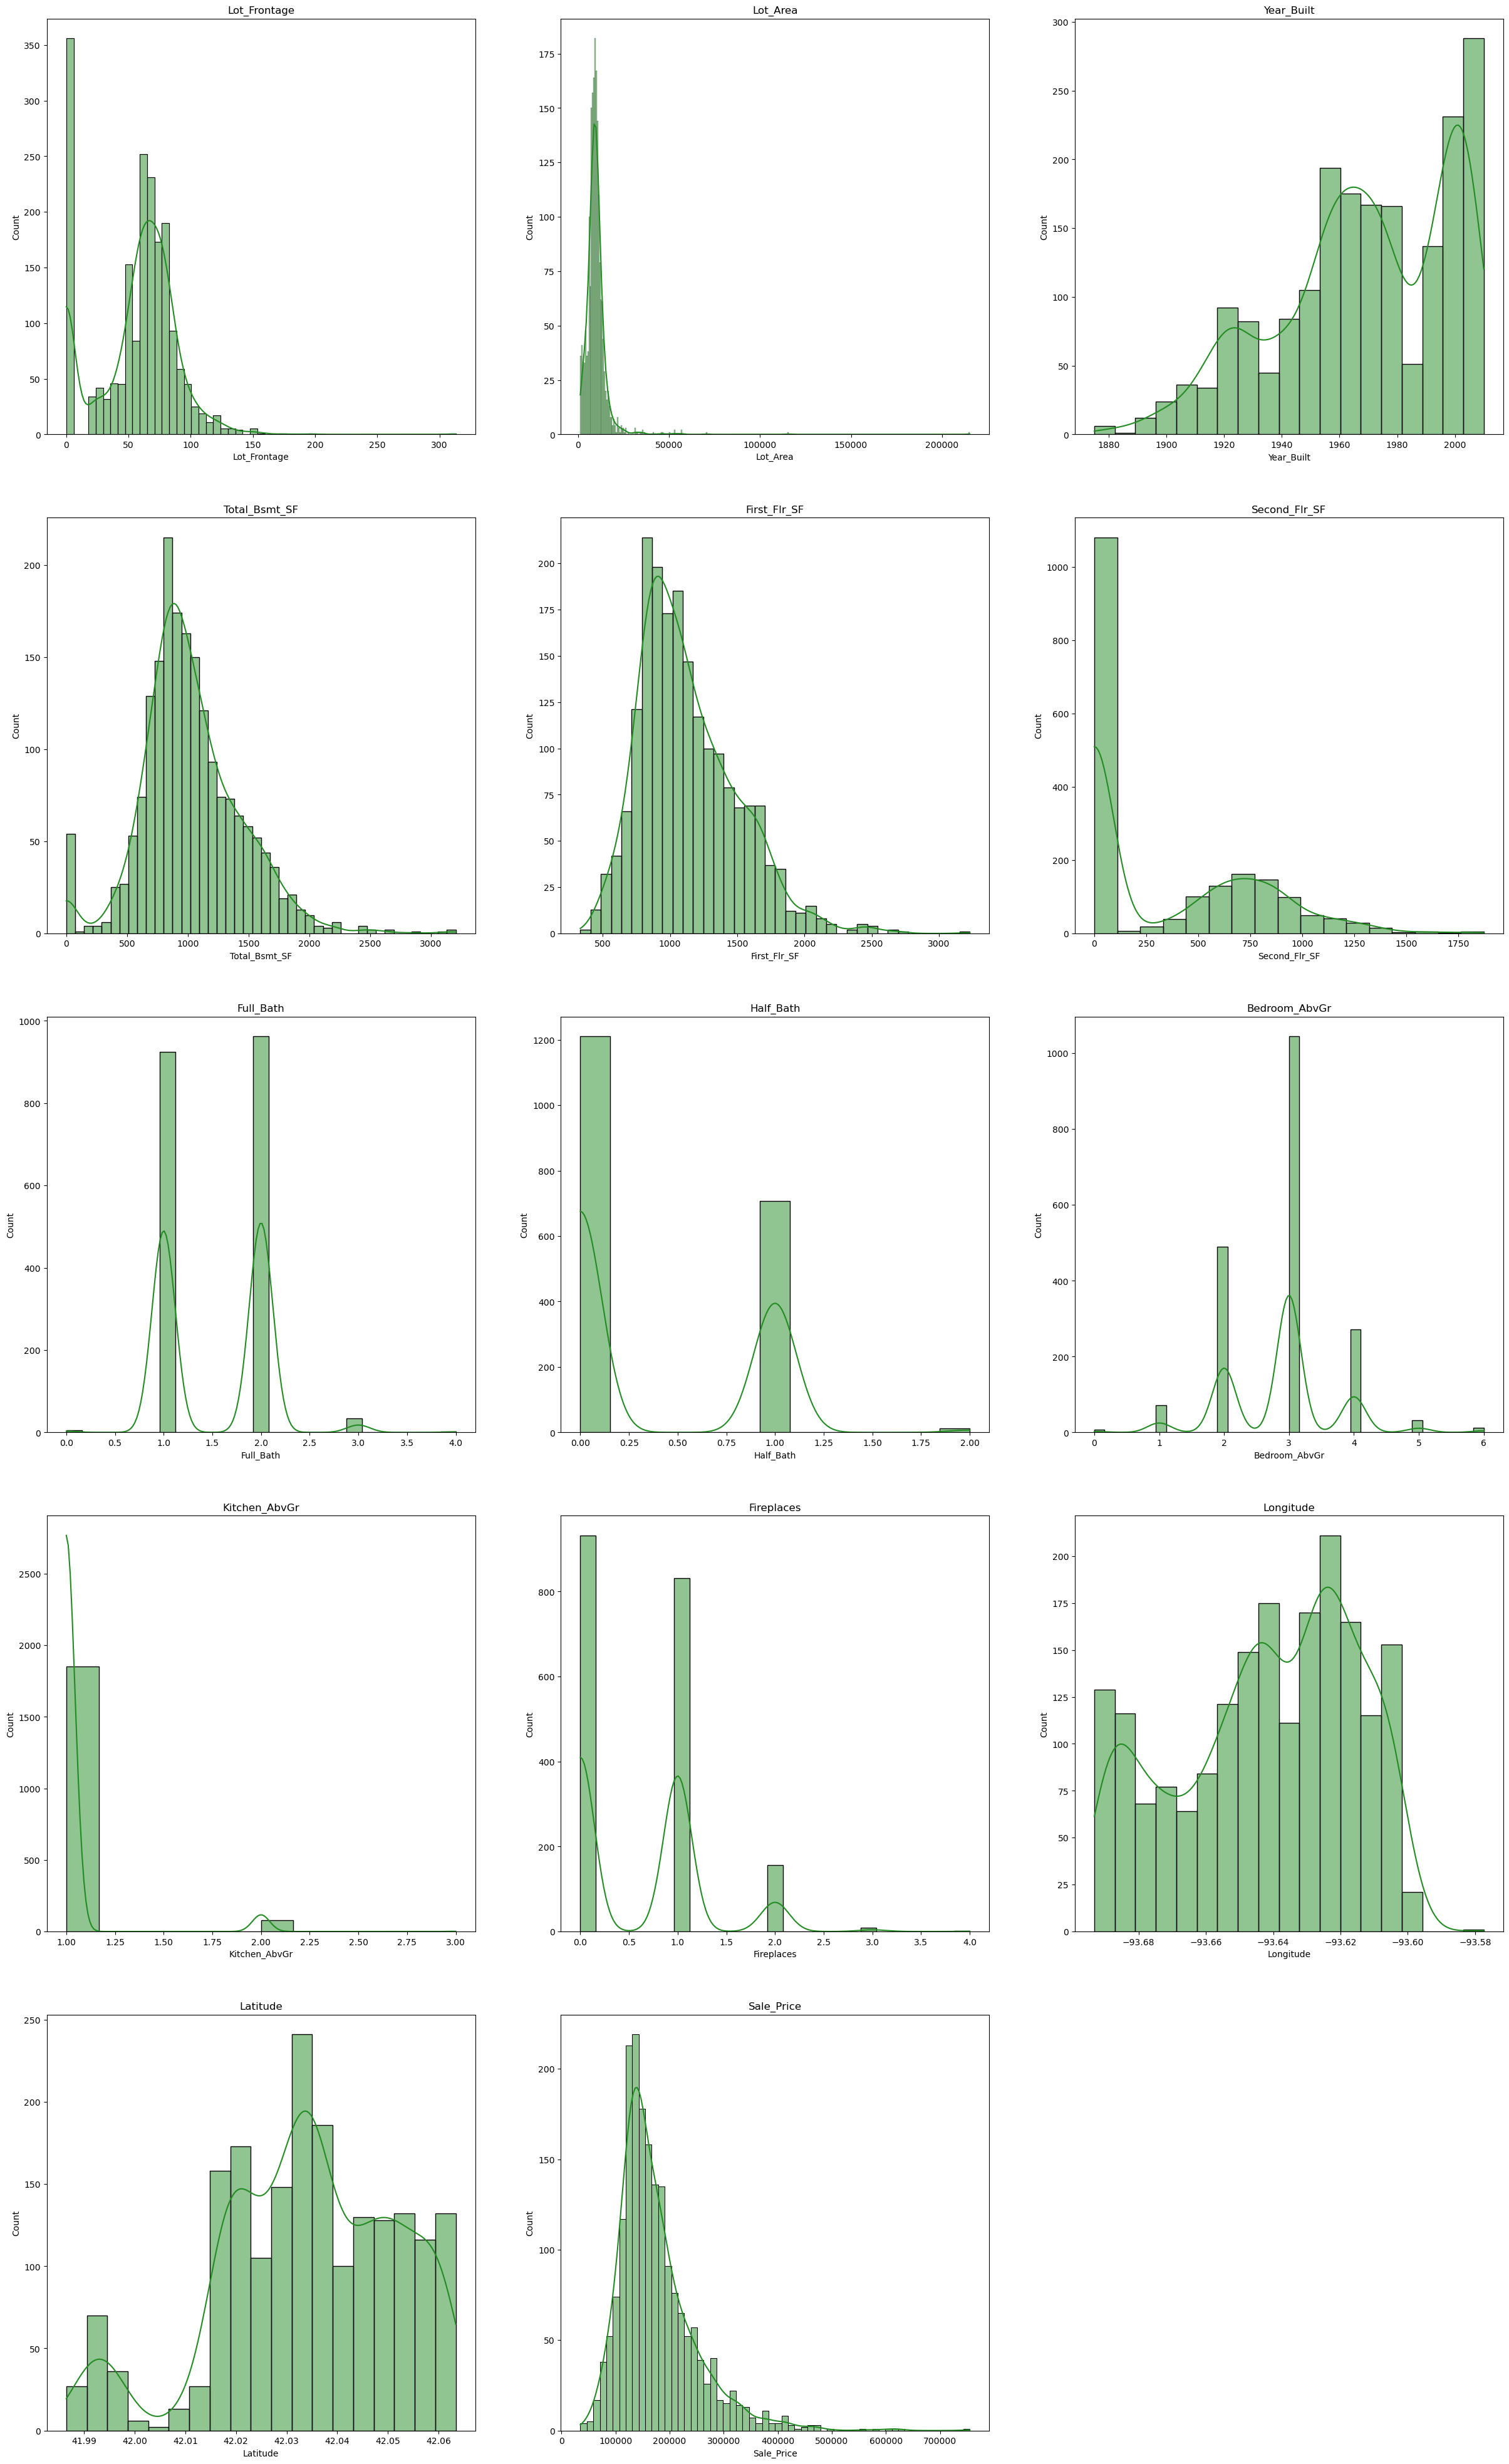

In [11]:
# histogram to visualize the spread of data to understand the spread
fig, axes = plt.subplots(nrows = 5, ncols = 3)  
axes = axes.flatten()         
fig.set_size_inches(30, 50)

for ax, col in zip(axes, numerical_columns.columns):
  sns.histplot(numerical_columns[col], ax = ax,kde=True, color='forestgreen')
  ax.set_title(col)
fig.delaxes(axes[14])
#skewness in certain independent features and dependent variable(Sale_Price) identified

In [12]:
#distribution of average sales price of the house vs the Building type

import plotly.express as px

Bldg_Type_housing_prices = train_data.groupby('Bldg_Type')['Sale_Price'].mean()
fig3 = px.bar(x=Bldg_Type_housing_prices.index, y=Bldg_Type_housing_prices.values, title='Average Sale Price by Bldg_Type', text=Bldg_Type_housing_prices.values)

fig3.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig3.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig3.update_xaxes(title='Building type')
fig3.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig3.show()

In [13]:
# ditribution of average Sale price of the house vs house style
import plotly.express as px

House_Style_prices = train_data.groupby('House_Style')['Sale_Price'].mean()
fig4 = px.bar(x=House_Style_prices.index, y=House_Style_prices.values, title='Average Sale Price by Bldg_Type', text=House_Style_prices.values)

fig4.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig4.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig4.update_xaxes(title='House Style')
fig4.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig4.show()

In [14]:
#distribution of average sale price vs overall condition 
import plotly.express as px

Overall_Cond_prices = train_data.groupby('Overall_Cond')['Sale_Price'].mean()
fig5 = px.bar(x=Overall_Cond_prices.index, y=Overall_Cond_prices.values, title='Average Sale Price by Overall_Cond', text=Overall_Cond_prices.values)

fig5.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig5.update_yaxes(title='Sale Price', tickprefix='$', tickformat=',')
fig5.update_xaxes(title='Overall_Cond')
fig5.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

fig5.show()

In [15]:
#distribution of the age of the house vs Sale price 
train_data['Age']=2010-train_data['Year_Built']

age_price_corr = train_data['Age'].corr(train_data['Sale_Price'])

# Create a scatter plot to visualize the relationship between Property Age and Sale Price
fig9 = px.scatter(train_data, x='Age', y='Sale_Price', title='Property Age vs Sale Price')

fig9.show()

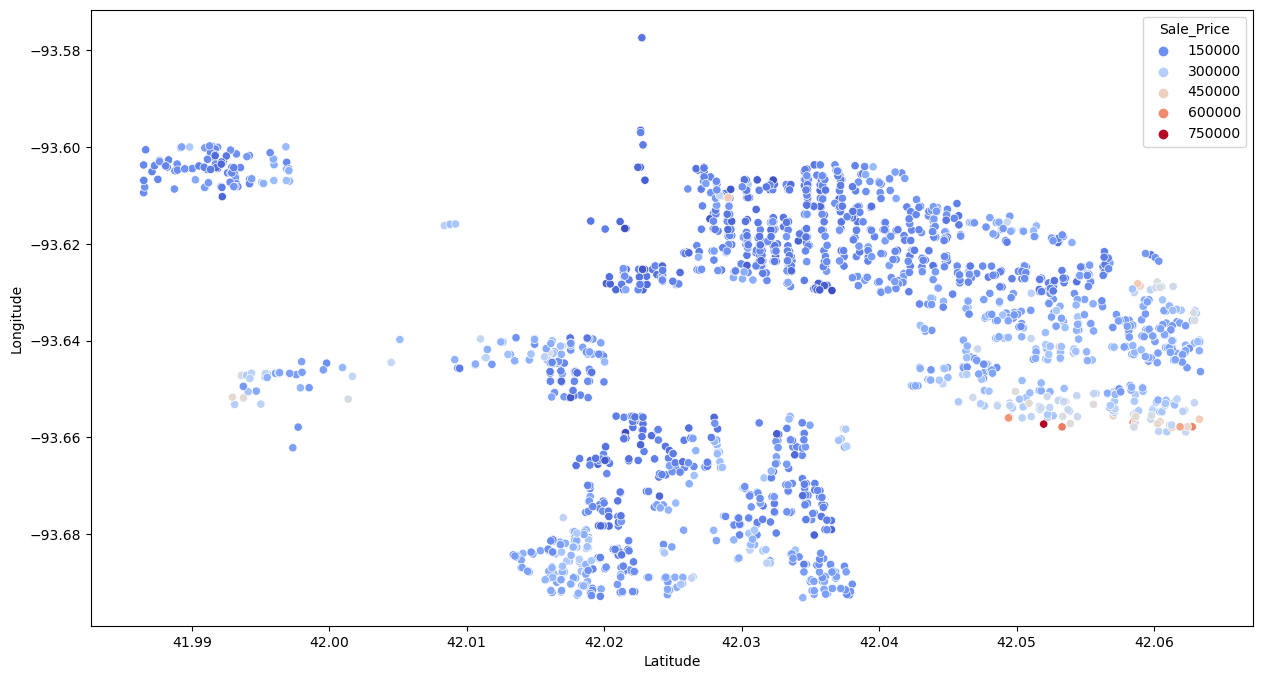

In [16]:
#distribution of geological coordinates against the sale price
plot.figure(figsize=(15,8))
sns.scatterplot(x='Latitude',y='Longitude',data=train_data,hue='Sale_Price',palette='coolwarm')
plot.show()

In [17]:
# dropping the Year_built as we transformed it to the Age of the house
train_data=train_data.drop('Year_Built',axis=1)


In [18]:
#Calculating the Z-Score of the numerical features and with the threshold of 3 standard deviation from the mean 
#, removed the outliers and stored in a variable

z_score = (numerical_columns - numerical_columns.mean())/ numerical_columns.std()
# z_score
threshold =  3
outliers = numerical_columns[abs(z_score) > threshold]
train_data_clean = train_data[(z_score < threshold).all(axis=1)]
train_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1779 entries, 1847 to 1532
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Lot_Frontage   1779 non-null   int64  
 1   Lot_Area       1779 non-null   int64  
 2   Bldg_Type      1779 non-null   object 
 3   House_Style    1779 non-null   object 
 4   Overall_Cond   1779 non-null   object 
 5   Exter_Cond     1779 non-null   object 
 6   Total_Bsmt_SF  1779 non-null   int64  
 7   First_Flr_SF   1779 non-null   int64  
 8   Second_Flr_SF  1779 non-null   int64  
 9   Full_Bath      1779 non-null   int64  
 10  Half_Bath      1779 non-null   int64  
 11  Bedroom_AbvGr  1779 non-null   int64  
 12  Kitchen_AbvGr  1779 non-null   int64  
 13  Fireplaces     1779 non-null   int64  
 14  Longitude      1779 non-null   float64
 15  Latitude       1779 non-null   float64
 16  Sale_Price     1779 non-null   int64  
 17  Age            1779 non-null   int64  
dtypes: float64

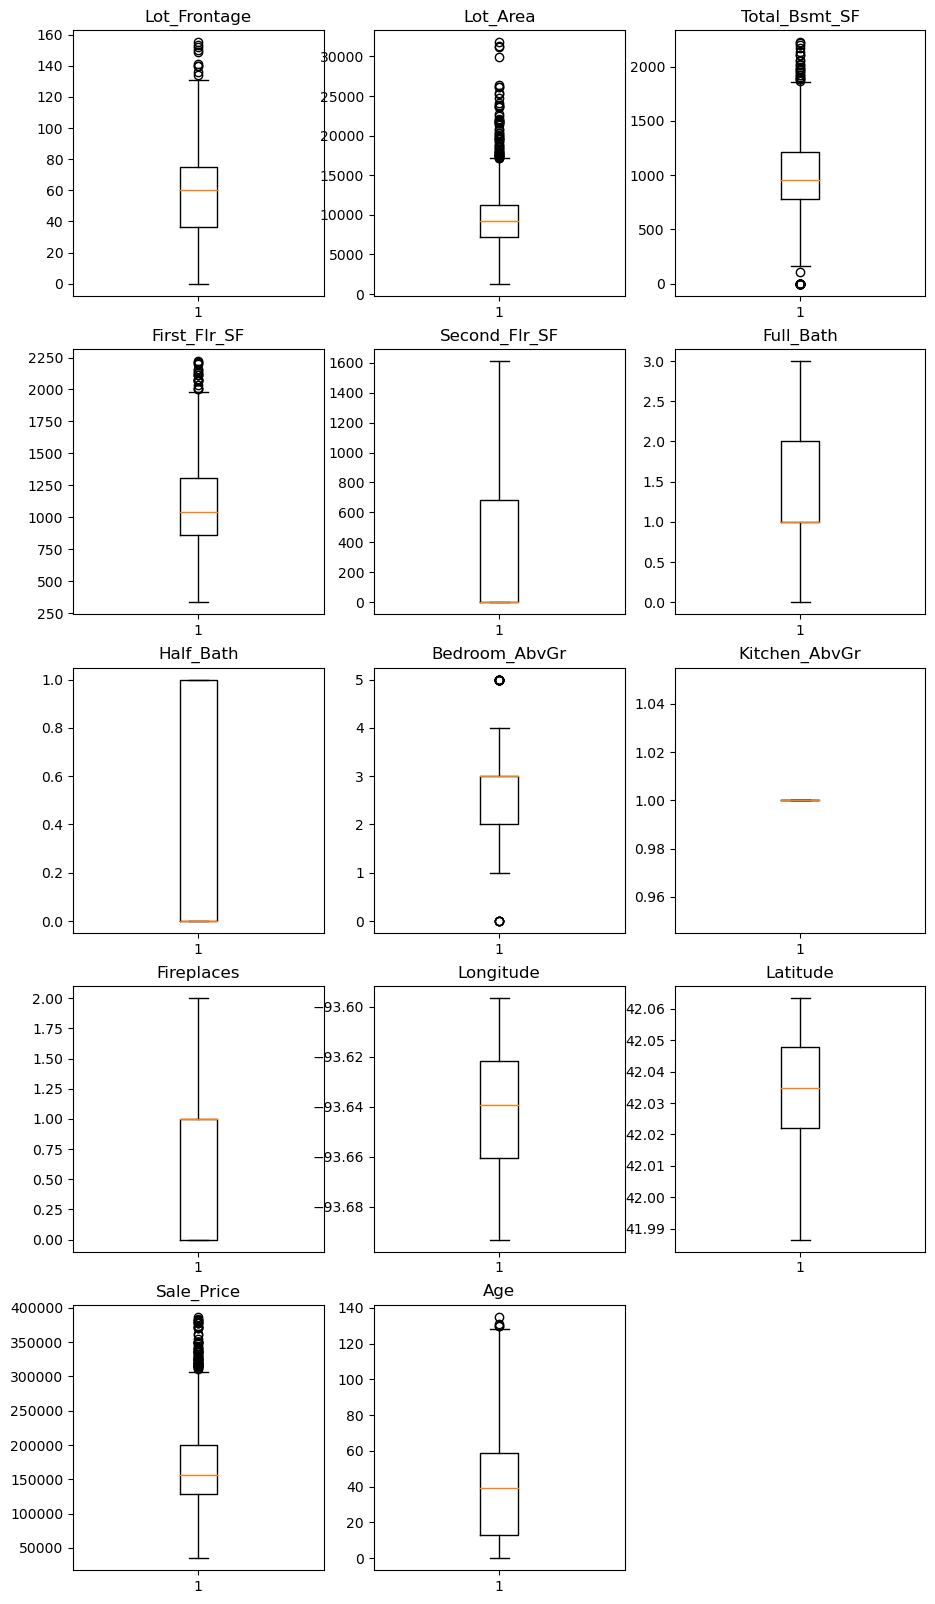

In [19]:
# visualizing again to check the removal of outliers from the dataset
#Boxplot to check the spread of the data

clean_numeric=train_data_clean.select_dtypes(["int64","float64"])
num_cols = 14
num_rows = 3
fig, axes = plt.subplots(5, 3, figsize=(11, 20))
axes = axes.flatten()

for i, j in enumerate(clean_numeric.columns):
    if i < num_cols:
        ax = axes[i]
        ax.boxplot(clean_numeric[j])
        ax.set_title(j)
fig.delaxes(axes[14])

plt.show()

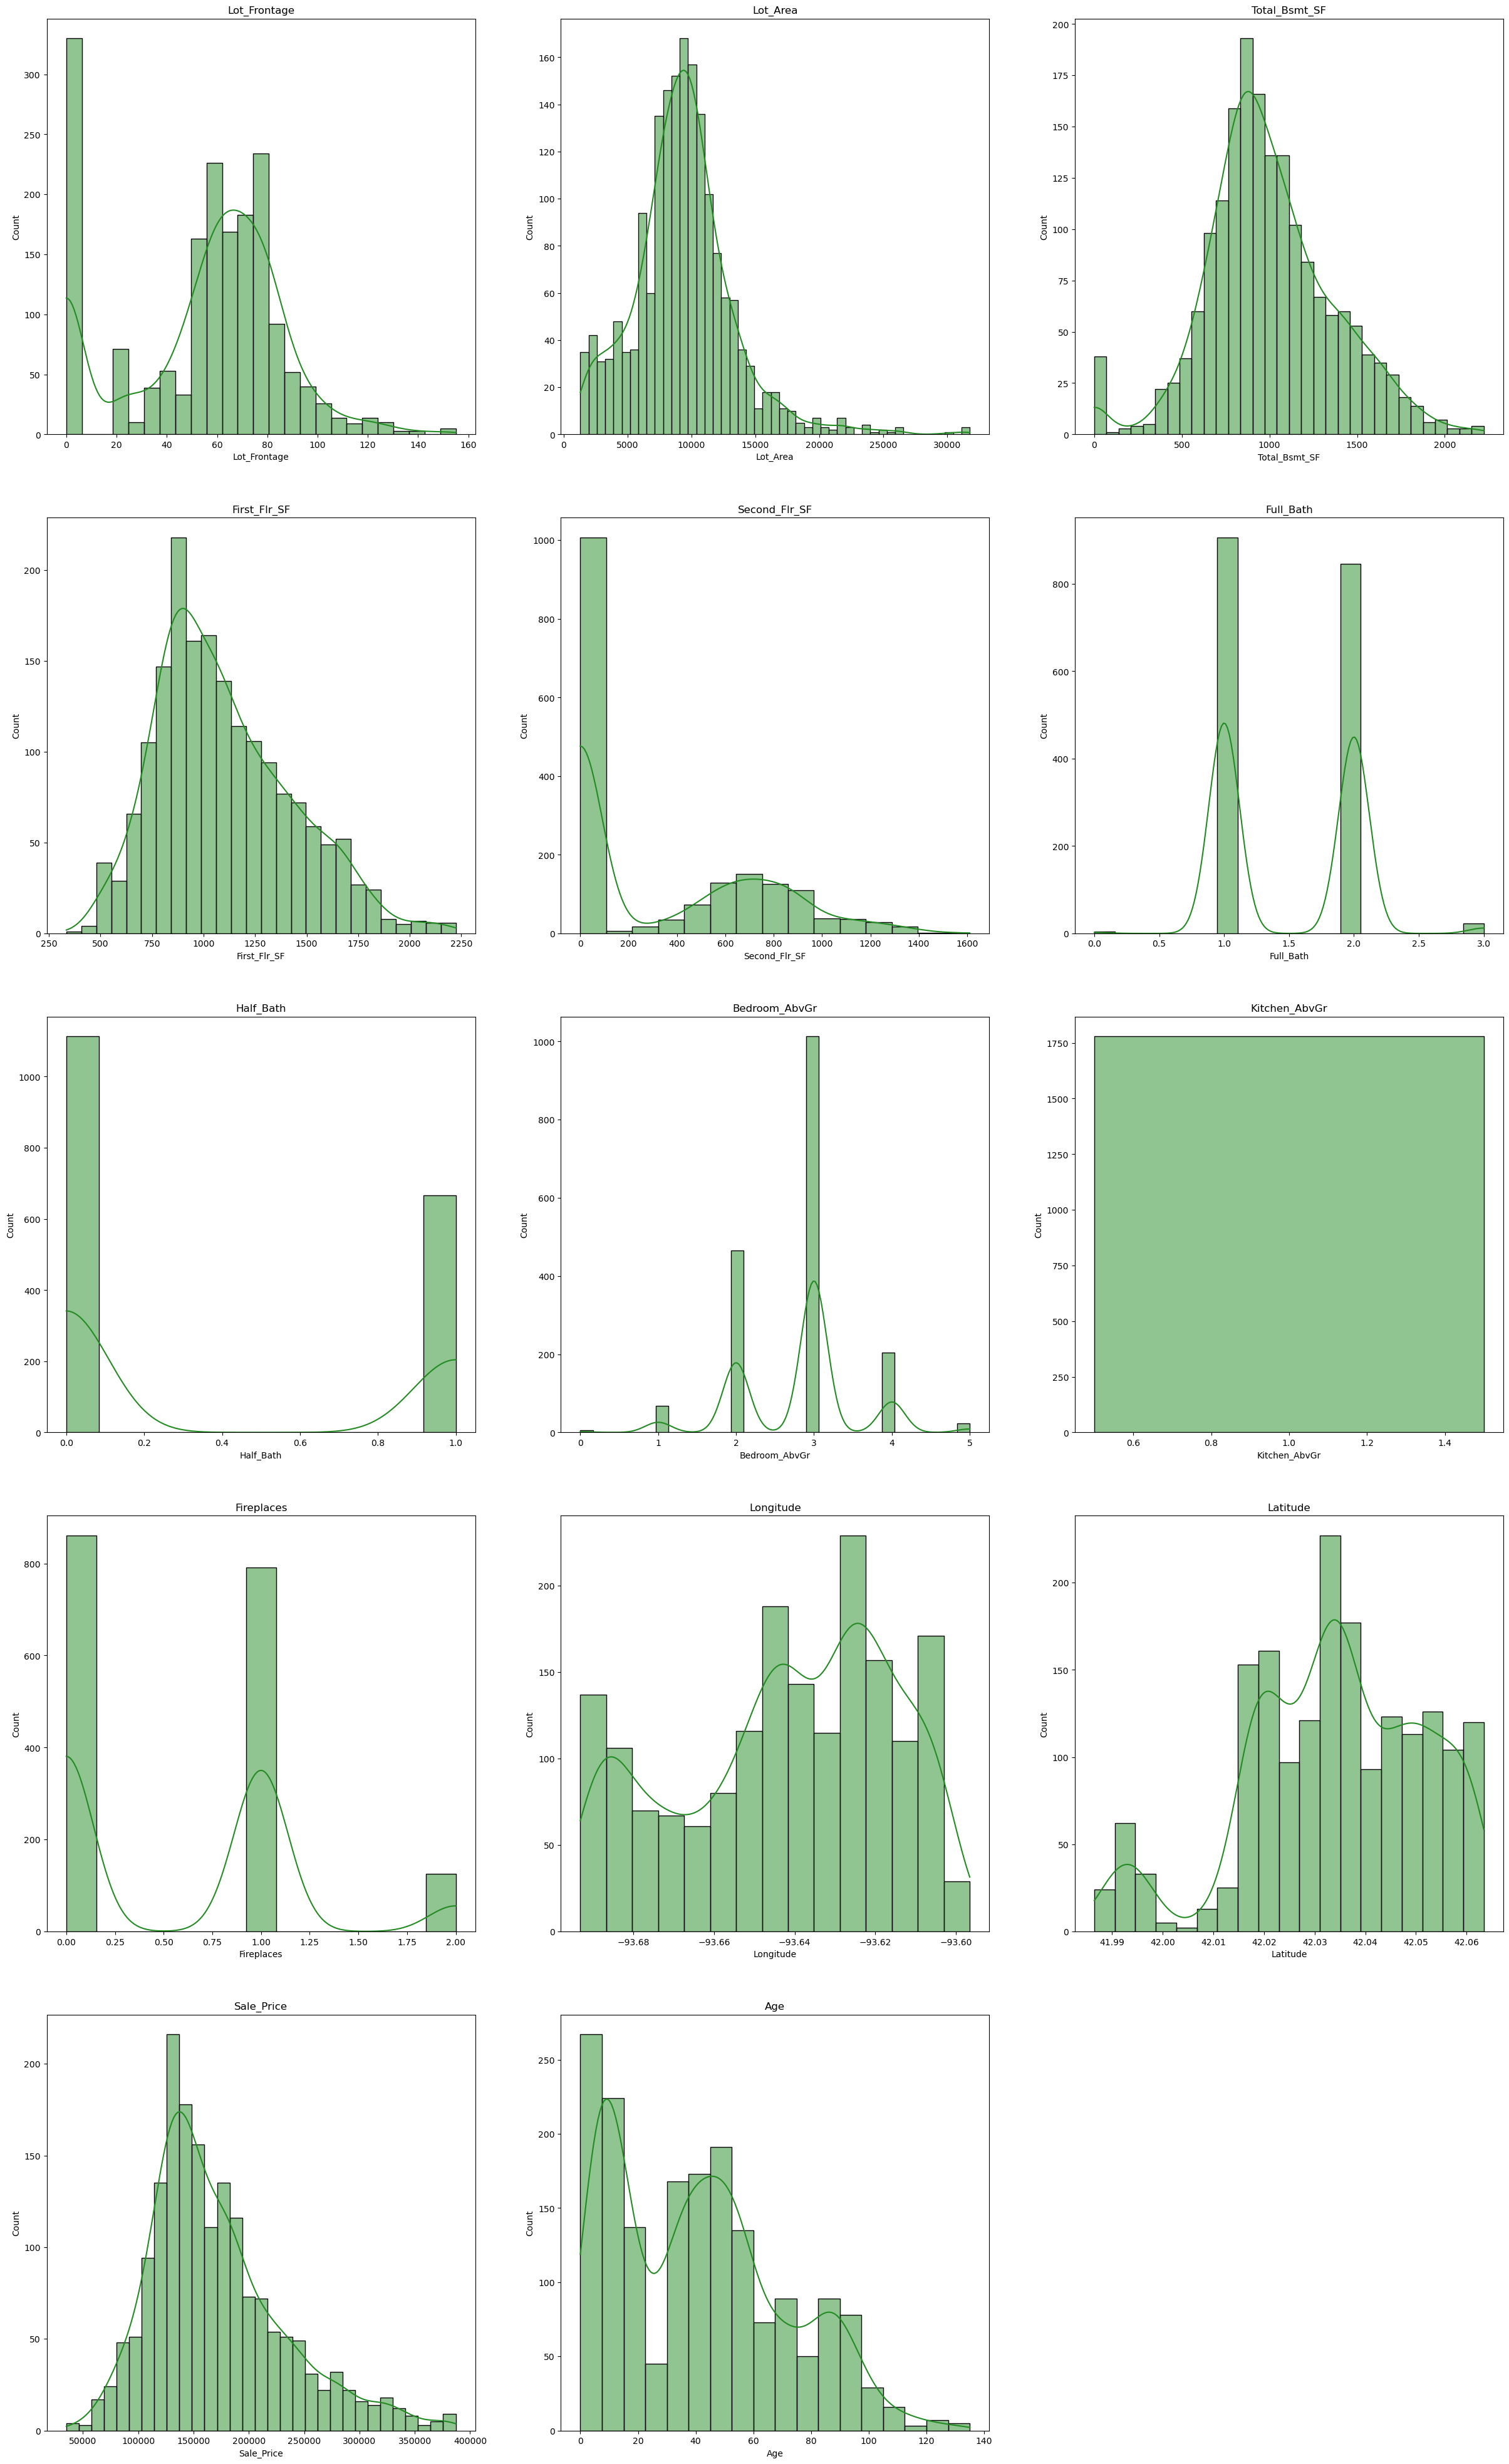

In [20]:
#plotting a histogram to see the distribution of numerical data after removing outliers

fig, axes = plt.subplots(nrows = 5, ncols = 3)    
axes = axes.flatten()         
fig.set_size_inches(30, 50)

for ax, col in zip(axes, clean_numeric.columns):
    sns.histplot(clean_numeric[col], ax = ax,kde=True, color='forestgreen')
    ax.set_title(col)
fig.delaxes(axes[14])

In [21]:
# dropping Kitchen_AbvGr variable from training data as it is same for all the observations

train_data_clean=train_data_clean.drop('Kitchen_AbvGr',axis=1)

In [22]:
train_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1779 entries, 1847 to 1532
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Lot_Frontage   1779 non-null   int64  
 1   Lot_Area       1779 non-null   int64  
 2   Bldg_Type      1779 non-null   object 
 3   House_Style    1779 non-null   object 
 4   Overall_Cond   1779 non-null   object 
 5   Exter_Cond     1779 non-null   object 
 6   Total_Bsmt_SF  1779 non-null   int64  
 7   First_Flr_SF   1779 non-null   int64  
 8   Second_Flr_SF  1779 non-null   int64  
 9   Full_Bath      1779 non-null   int64  
 10  Half_Bath      1779 non-null   int64  
 11  Bedroom_AbvGr  1779 non-null   int64  
 12  Fireplaces     1779 non-null   int64  
 13  Longitude      1779 non-null   float64
 14  Latitude       1779 non-null   float64
 15  Sale_Price     1779 non-null   int64  
 16  Age            1779 non-null   int64  
dtypes: float64(2), int64(11), object(4)
memory usage: 250.

## Encoding for Categorical features in Dataset

In [23]:
#Encoding Categorical - Ordinal variables with increasing numbers 1,2,3.. as it follows an order which can be related

#creating a dictionary for the ordinal values and mapping it to the required feature in the dataset
dataMapping={"Very_Poor":1,"Poor":2,"Fair":3,"Below_Average":4,"Average":5,"Above_Average":6,"Good":7,"Very_Good":8,"Excellent":9}
train_data_clean['Overall_Cond_Num']=train_data_clean['Overall_Cond'].map(dataMapping)

dataMapping2={"Poor":1,"Fair":2,"Typical":3,"Good":4,"Excellent":5}
train_data_clean['Exter_Cond_Num']=train_data_clean['Exter_Cond'].map(dataMapping2)
train_data_clean=train_data_clean.drop(['Exter_Cond','Overall_Cond'],axis=1)


#Encoding Categorical - Nominal variables with dummies as this doesnt follow any specific order 
# Creating dummies from Pandas for each categorical feature to create a binary encoding of the observation with 0 and 1 

train_data_clean=train_data_clean.join(pd.get_dummies(train_data_clean.House_Style,dtype=int)).drop(['House_Style'],axis=1)
train_data_clean=train_data_clean.join(pd.get_dummies(train_data_clean.Bldg_Type,dtype=int)).drop(['Bldg_Type'],axis=1)

#to avoid dummy variable trap, 2 of the columns were dropped from the model
train_data_clean=train_data_clean.drop(['One_and_Half_Unf'],axis=1)
train_data_clean=train_data_clean.drop(['OneFam'],axis=1)

In [24]:
train_data_clean.describe()

,Lot_Frontage,Lot_Area,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Full_Bath,Half_Bath,Bedroom_AbvGr,Fireplaces,Longitude,Latitude,Sale_Price,Age,Overall_Cond_Num,Exter_Cond_Num,One_Story,One_and_Half_Fin,SFoyer,SLvl,Two_Story,Two_and_Half_Fin,Two_and_Half_Unf,Duplex,Twnhs,TwnhsE,TwoFmCon
count,1779.000000,1779.00000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.00000,1779.00000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000,1779.000000
mean,54.487915,9367.69140,999.660483,1100.151771,325.749297,1.499157,0.374368,2.793704,0.586847,-93.642047,42.034035,170759.671726,41.024733,5.685779,3.100056,0.489601,0.118044,0.030354,0.04778,0.29511,0.001686,0.007307,0.003935,0.041596,0.083755,0.009556
std,32.168623,3899.59127,365.734834,329.588996,405.212991,0.529633,0.484095,0.751186,0.619941,0.026236,0.017644,60865.668107,29.358370,1.113712,0.375119,0.500032,0.322751,0.171608,0.21336,0.45622,0.041042,0.085195,0.062622,0.199721,0.277098,0.097314
min,0.000000,1300.00000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-93.693153,41.986498,35000.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.500000,7200.00000,780.000000,861.000000,0.000000,1.000000,0.000000,2.000000,0.000000,-93.660672,42.022090,129100.000000,13.000000,5.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,60.000000,9240.00000,957.000000,1042.000000,0.000000,1.000000,0.000000,3.000000,1.000000,-93.639366,42.034663,157000.000000,39.000000,5.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75.000000,11196.00000,1212.000000,1310.000000,686.000000,2.000000,1.000000,3.000000,1.000000,-93.621503,42.047794,200000.000000,59.000000,6.000000,3.000000,1.000000,0.000000,0.000000,0.00000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,155.000000,31770.00000,2223.000000,2223.000000,1611.000000,3.000000,1.000000,5.000000,2.000000,-93.596569,42.063381,387000.000000,135.000000,9.000000,5.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
#skewness of the data is verified to check if any continuous data is distributed along a side
train_data_clean.skew()


Lot_Frontage        -0.372706
Lot_Area             0.969053
Total_Bsmt_SF        0.180816
First_Flr_SF         0.650719
Second_Flr_SF        0.740184
Full_Bath            0.219386
Half_Bath            0.519624
Bedroom_AbvGr       -0.160012
Fireplaces           0.561090
Longitude           -0.397281
Latitude            -0.521517
Sale_Price           0.973171
Age                  0.527013
Overall_Cond_Num     0.622451
Exter_Cond_Num       1.590677
One_Story            0.041641
One_and_Half_Fin     2.369544
SFoyer               5.479633
SLvl                 4.243814
Two_Story            0.899219
Two_and_Half_Fin    24.310453
Two_and_Half_Unf    11.579274
Duplex              15.860989
Twnhs                4.595601
TwnhsE               3.007700
TwoFmCon            10.091006
dtype: float64

In [26]:
#square root transformation of the dependent variable is applied to create a more normal distribution
train_data_clean['Sale_Price']=np.sqrt(train_data_clean['Sale_Price'])


<Axes: xlabel='Sale_Price', ylabel='Count'>

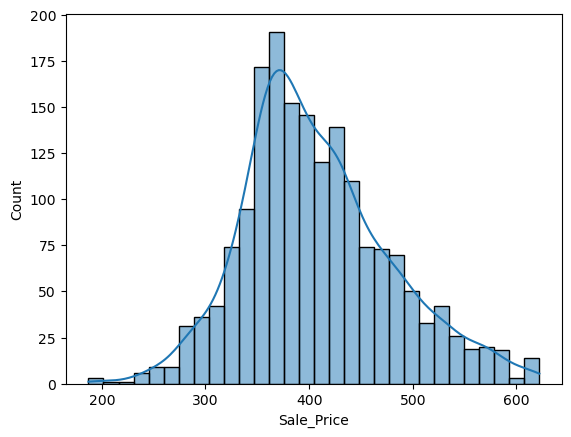

In [27]:
# Normal distribution of Sale price 
sns.histplot(train_data_clean['Sale_Price'],kde=True)

In [28]:
#splitting the train data to fit in the model and check
x_train = train_data_clean.drop(["Sale_Price"], axis=1)
y_train = train_data_clean["Sale_Price"]

In [29]:
#summary of the initial model is printed
x_train = sm.add_constant(x_train)
model = sm.OLS(y_train,x_train)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     461.0
Date:                Sun, 26 Nov 2023   Prob (F-statistic):               0.00
Time:                        01:37:33   Log-Likelihood:                -8312.3
No. Observations:                1779   AIC:                         1.668e+04
Df Residuals:                    1753   BIC:                         1.682e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -1.33e+04   3221.515  

In [30]:
# droping the variables that are insignificant to the model
x_train=x_train.drop(['Half_Bath','Exter_Cond_Num','One_Story','One_and_Half_Fin','SFoyer','SLvl','Two_Story','Two_and_Half_Fin','Two_and_Half_Unf','Duplex','TwnhsE','TwoFmCon'],axis=1)

In [31]:
#printing summary statistic of the intermediary model
model = sm.OLS(y_train,x_train)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     883.3
Date:                Sun, 26 Nov 2023   Prob (F-statistic):               0.00
Time:                        01:37:33   Log-Likelihood:                -8320.3
No. Observations:                1779   AIC:                         1.667e+04
Df Residuals:                    1765   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.258e+04   3170.603  

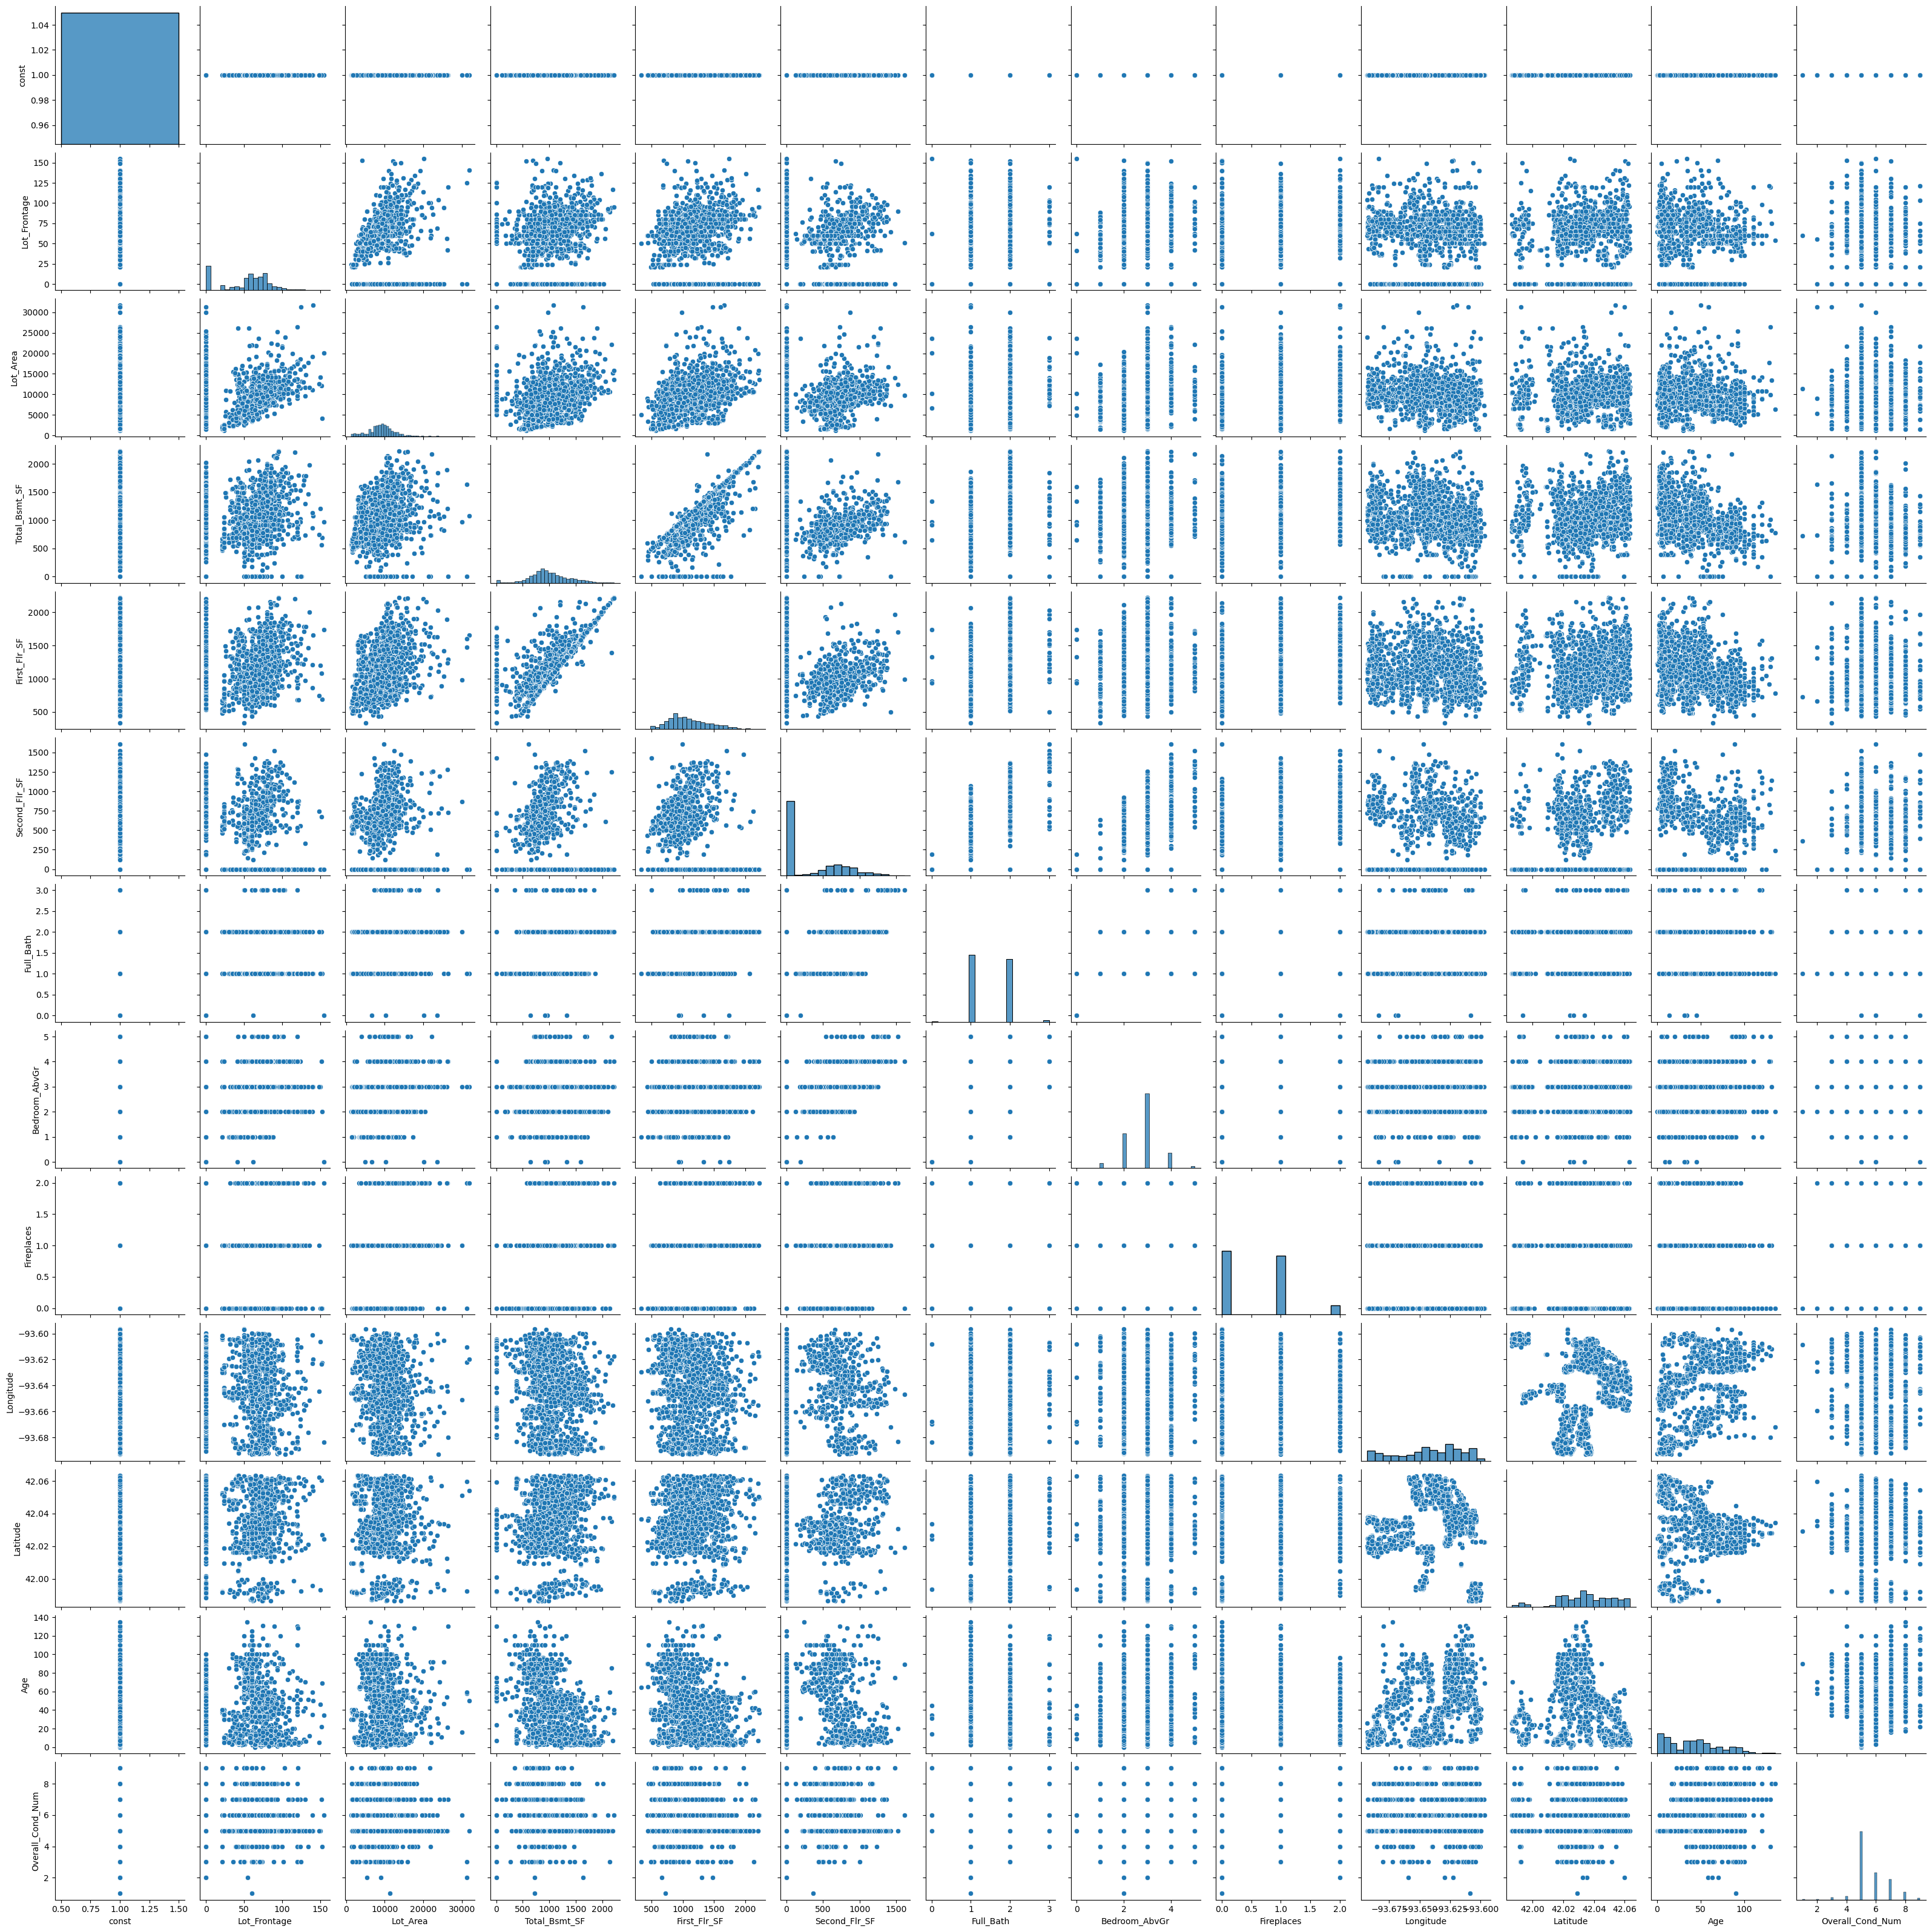

In [32]:
#pairplot to identify linear relationship between variables in intermediate model
sns.pairplot(x_train.select_dtypes(["int64","float64"]))
plt.show()

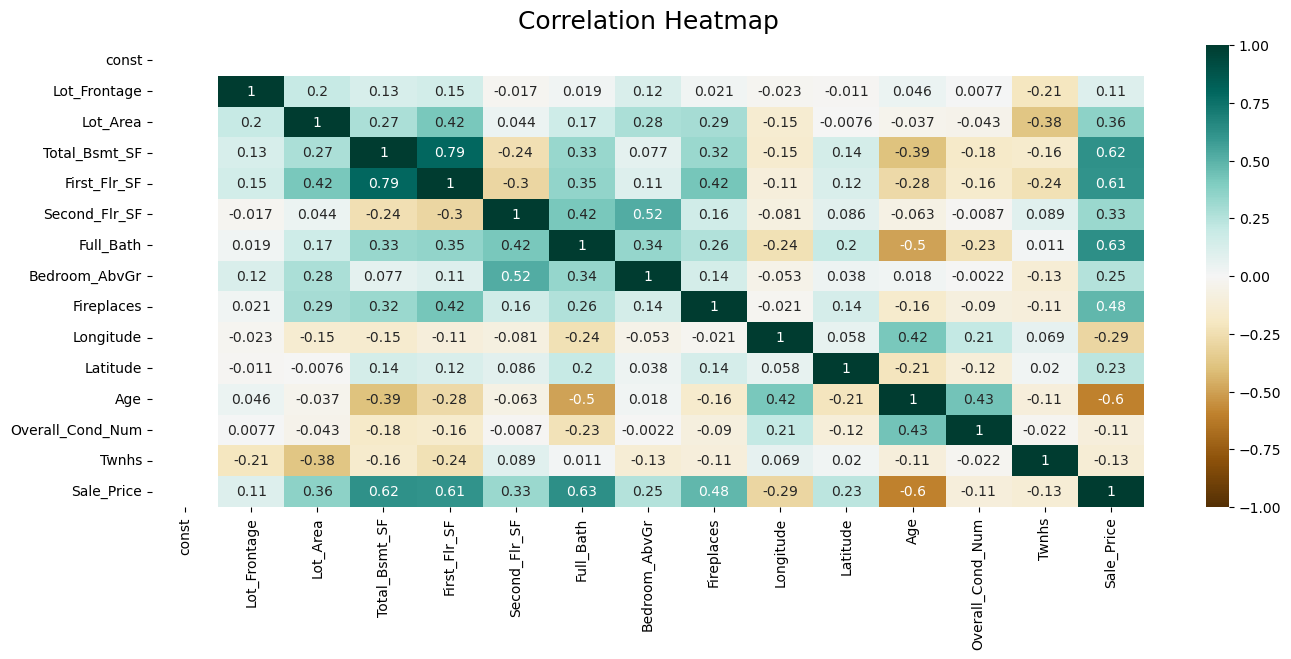

In [33]:
# plotting a correlation heatmap to check for verifying any multicollinearity between the independent variables
#and also the correlation between the independent and dependent variables
corr_chart=x_train.join(y_train)
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(corr_chart.select_dtypes(["int64","float64","int32"]).corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)
plt.show()


In [34]:
#dropping Total Basement SF as it shows strong collinearity with Total basement SF and printing the summary
x_train=x_train.drop(['Total_Bsmt_SF'],axis=1)
model = sm.OLS(y_train,x_train)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     824.9
Date:                Sun, 26 Nov 2023   Prob (F-statistic):               0.00
Time:                        01:38:32   Log-Likelihood:                -8434.0
No. Observations:                1779   AIC:                         1.689e+04
Df Residuals:                    1766   BIC:                         1.697e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.357e+04   3378.229  

In [35]:
#calculating Variance Inflation Factor for the independent variables in the model
VIFt=x_train.join(y_train)
vif = pd.DataFrame()
vif["variables"] = VIFt.columns
vif["VIF"] = [variance_inflation_factor(VIFt.values, i) for i in range(VIFt.shape[1])]
print(vif)
#VIF is acceptable range of less than 5 for the independent variables

           variables           VIF
0              const  2.648030e+07
1       Lot_Frontage  1.092209e+00
2           Lot_Area  1.520962e+00
3       First_Flr_SF  4.831200e+00
4      Second_Flr_SF  4.286844e+00
5          Full_Bath  2.173214e+00
6      Bedroom_AbvGr  1.773833e+00
7         Fireplaces  1.467238e+00
8          Longitude  1.311277e+00
9           Latitude  1.114520e+00
10               Age  3.237634e+00
11  Overall_Cond_Num  1.517689e+00
12             Twnhs  1.272977e+00
13        Sale_Price  6.605139e+00


In [36]:
#refitting the model after removing the features due to VIF, Skewness 

x =VIFt.drop(["Sale_Price"], axis=1)
# x = sm.add_constant(x)
model = sm.OLS(VIFt['Sale_Price'],x)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:             Sale_Price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     824.9
Date:                Sun, 26 Nov 2023   Prob (F-statistic):               0.00
Time:                        01:38:32   Log-Likelihood:                -8434.0
No. Observations:                1779   AIC:                         1.689e+04
Df Residuals:                    1766   BIC:                         1.697e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.357e+04   3378.229  

## Test data preprocessing

In [37]:
#preparing the test data and applying all the variable transformation to the testing dataset

test_data['Age']=2010-test_data['Year_Built']
test_data=test_data.drop('Year_Built',axis=1)


In [38]:
#transformation of Sale Price
test_data['Sale_Price']=np.sqrt(test_data['Sale_Price'])

In [39]:
#datamapping and adding dummies to the categorical data
dataMapping={"Very_Poor":1,"Poor":2,"Fair":3,"Below_Average":4,"Average":5,"Above_Average":6,"Good":7,"Very_Good":8,"Excellent":9}
test_data['Overall_Cond_Num']=test_data['Overall_Cond'].map(dataMapping)

dataMapping2={"Poor":1,"Fair":2,"Typical":3,"Good":4,"Excellent":5}
test_data['Exter_Cond_Num']=test_data['Exter_Cond'].map(dataMapping2)

test_data=test_data.drop(['Exter_Cond','Overall_Cond'],axis=1)


test_data=test_data.join(pd.get_dummies(test_data.House_Style,dtype=int)).drop(['House_Style'],axis=1)
test_data=test_data.join(pd.get_dummies(test_data.Bldg_Type,dtype=int)).drop(['Bldg_Type'],axis=1)

test_data_model=test_data

In [40]:
#dropping the columns from test dataset not in the model fitted
test_data_model=test_data_model.drop(['Total_Bsmt_SF','Half_Bath','Kitchen_AbvGr','Exter_Cond_Num','One_Story','One_and_Half_Fin','SFoyer','SLvl','Two_Story','Two_and_Half_Fin','Two_and_Half_Unf','Duplex','OneFam','TwnhsE','TwoFmCon','Sale_Price'],axis=1)

In [41]:
test_data_model=test_data_model.join(test_data.Sale_Price)

In [42]:
test_data_model

,Lot_Frontage,Lot_Area,First_Flr_SF,Second_Flr_SF,Full_Bath,Bedroom_AbvGr,Fireplaces,Longitude,Latitude,Age,Overall_Cond_Num,Twnhs,Sale_Price
1060,80,9600,1496,0,2,3,0,-93.628507,42.038058,50,6,0,376.164857
403,63,10928,728,728,2,3,1,-93.645752,42.062320,5,5,0,428.952212
375,97,13478,1728,568,2,3,1,-93.658224,42.062776,2,5,0,672.272266
1274,70,8750,933,975,2,4,1,-93.679940,42.017866,16,5,0,458.257569
2352,43,7000,743,736,1,3,2,-93.646619,42.019093,84,8,0,400.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,60,5790,840,765,2,3,0,-93.614002,42.033279,95,6,0,327.719392
1370,82,11202,1440,0,2,3,1,-93.646726,41.995512,7,5,0,482.182538
1733,138,18030,1636,971,3,3,1,-93.656124,42.033285,64,6,0,447.772264
246,64,6410,960,0,1,3,0,-93.666337,42.019629,52,5,0,300.000000


## Calculating the predicted value of the test from the model

In [43]:
#preparing the data for fitting in the regression model for prediction
x_test= sm.add_constant(test_data_model)


In [44]:
#splitting the independent variables and dependent variable in the test dataset
X_test = x_test.drop(["Sale_Price"], axis=1)
Y_test = x_test["Sale_Price"]

In [45]:
#calling the predict method for calculating the predicted values from the model
y_pred=fit.predict(X_test)

In [46]:
#predicted sale_price
y_pred

1060    420.227316
403     435.659188
375     559.642459
1274    456.097703
2352    386.508021
           ...    
153     349.271165
1370    451.978649
1733    538.390843
246     327.765699
2200    306.968623
Length: 483, dtype: float64

In [47]:
#calculating the MAE for the predicted values
meanabserror = mean_absolute_error(Y_test,y_pred)
meanabserror

23.042348119030713

In [48]:
#Calculating MAPE for the actual and predicted values
mean_absolute_percentage_error(Y_test,y_pred)

0.05604738063478435

In [49]:
#calculating the individual residuals or errors
errors=y_pred-Y_test
errors

1060     44.062459
403       6.706977
375    -112.629807
1274     -2.159866
2352    -13.491979
           ...    
153      21.551773
1370    -30.203889
1733     90.618580
246      27.765699
2200     -4.319025
Length: 483, dtype: float64

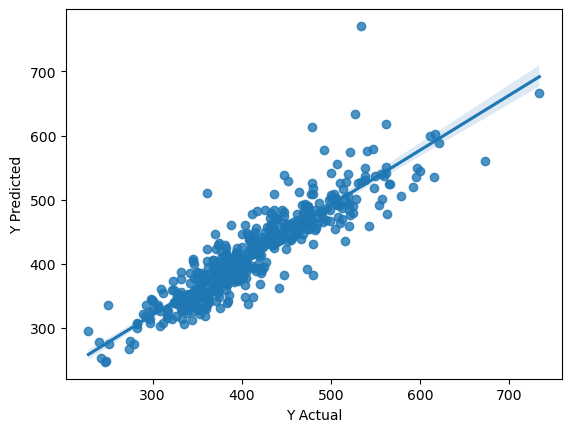

In [50]:
#Regplot for the Y Actual Vs Y predicted
fig= sns.regplot(x=Y_test, y=y_pred,x_ci=95)
fig.set(xlabel='Y Actual', ylabel='Y Predicted')
plt.show()

## Residual Analysis to test Gauss Markov assumptions

In [51]:
#calculating the required variables for plotting the QQ plot and Residual vs Fitted plot
y_hat=fit.fittedvalues.to_list()
residuals=fit.resid
influence=fit.get_influence()
sandardised_residuals=influence.resid_studentized_internal
studentised_residuals=influence.resid_studentized_external
root_residuals=abs(studentised_residuals)**0.5
leverage=influence.hat_matrix_diag
cooks_distances,p= influence.cooks_distance

In [52]:
theoretical_quantiles=np.sort(np.random.normal(loc=0,scale=1,size=len(residuals)))
outliers=[i+1 if abs(s)>2 else "" for i,s in zip(range(len(fit.resid)),studentised_residuals)]
loess=sm.nonparametric.lowess(root_residuals,y_hat,it=0,delta=0.01 *(max(y_hat)-min(y_hat)))

In [53]:
#plotting a normal quantile-quantile plot
resid_dict=dict(zip(sandardised_residuals,outliers))
sorted_residuals=sorted(resid_dict)
sorted_outliers=[resid_dict[residual] for residual in sorted_residuals]
fig=go.Figure(go.Scatter(x=theoretical_quantiles,y=sorted_residuals,text=sorted_outliers,mode="markers+text",showlegend=False))
fig=fig.add_trace(go.Scatter(x=theoretical_quantiles,y=theoretical_quantiles,mode="lines",showlegend=False))
fig=fig.update_traces(textposition="middle left")
fig.update_layout(title="Normal QQ plot",xaxis_title="Theoreticalquantlies",yaxis_title="Standardised residuals")

In [54]:
#plotting Residual vs Fitted plot
fig=go.Figure(go.Scatter(x=y_hat,y=residuals,text=outliers,mode="markers+text",showlegend=False))
fig=fig.update_traces(textposition="middle left")
fig=fig.add_trace(go.Scatter(x=loess[:,0],y=loess[:,1],mode="lines",showlegend=False))
fig.update_layout(title="Residual vs Fitted Plot",xaxis_title="Fitted values",yaxis_title="Residuals")

In [55]:
#Calculation of MSE
mse= mean_squared_error(Y_test,y_pred)
mse

1081.2136360009624

In [56]:
#Calculation of RMSE
rmse=np.sqrt(mse)
rmse

32.881813149535446

In [57]:
#calculate Durbin Watson statistic for autocorrelation
durbin_watson_statistic = sm.stats.stattools.durbin_watson(fit.resid)
durbin_watson_statistic

# No autocorrelation since the statistic is closer to 2.

1.9588359796579353

In [58]:
#Breusch Pagan test for homoscedasticity
test_result = sms.het_breuschpagan(fit.resid, fit.model.exog)
names = ['Lagrange multiplier statistic', 'p-value',
        'f-value', 'f p-value']
lzip(names, test_result)

#P value is less than alpha and hence exhibit homoscedasticity

[('Lagrange multiplier statistic', 249.66336501389873),
 ('p-value', 1.6081869284977198e-46),
 ('f-value', 24.024877438584785),
 ('f p-value', 2.6299667365566217e-50)]

In [59]:
#Shapiro Wilk test for Normality
shapiro_test_result = st.shapiro(residuals)
shapiro_test_result

#P value is less than alpha and hence residuals are normally distributed 

ShapiroResult(statistic=0.984551191329956, pvalue=6.434130572080532e-13)